In [1]:
import pandas as pd

# Her problemin sonuçlarını oku
churn_results = pd.read_csv('churn_model_performance.csv')
revenue_results = pd.read_csv('revenue_model_performance.csv')
segmentation_results = pd.read_csv('segmentation_model_performance.csv')

print("=== PROBLEM 1: CHURN PREDICTION ===")
print(churn_results[['ModelName', 'Accuracy', 'Precision', 'Recall', 'F1Score', 'ROC_AUC']])
print()

print("=== PROBLEM 2: CUSTOMER SEGMENTATION ===")
print(segmentation_results[['ModelName', 'Algorithm', 'NumberOfClusters', 'SilhouetteScore']])
print()

print("=== PROBLEM 3: REVENUE PREDICTION ===")
print(revenue_results[['ModelName', 'Test_RMSE', 'Test_MAE', 'Test_R2']])

=== PROBLEM 1: CHURN PREDICTION ===
             ModelName  Accuracy  Precision    Recall   F1Score   ROC_AUC
0  Logistic Regression  0.819021   0.680982  0.595174  0.635193  0.861868
1        Random Forest  0.789212   0.638686  0.469169  0.540958  0.846002
2              XGBoost  0.794890   0.638158  0.520107  0.573117  0.840964

=== PROBLEM 2: CUSTOMER SEGMENTATION ===
               ModelName Algorithm  NumberOfClusters  SilhouetteScore
0  Customer Segmentation    KMeans                 4           0.2473

=== PROBLEM 3: REVENUE PREDICTION ===
                 ModelName    Test_RMSE    Test_MAE   Test_R2
0        Linear Regression  1122.486635  883.107026  0.757809
1  Random Forest Regressor  1067.840403  762.340221  0.780816


In [2]:
best_churn_model = churn_results.loc[churn_results['F1Score'].idxmax(), 'ModelName']
best_revenue_model = revenue_results.loc[revenue_results['Test_R2'].idxmax(), 'ModelName']

print(f"En iyi Churn modeli: {best_churn_model}")
print(f"En iyi Revenue modeli: {best_revenue_model}")
print(f"Segmentasyon modeli: KMeans (k=4, Silhouette Score: {segmentation_results['SilhouetteScore'].iloc[0]})")

En iyi Churn modeli: Logistic Regression
En iyi Revenue modeli: Random Forest Regressor
Segmentasyon modeli: KMeans (k=4, Silhouette Score: 0.2473)


In [5]:
final_summary = pd.DataFrame({
    'Problem': ['Churn Prediction', 'Churn Prediction', 'Churn Prediction',
                'Customer Segmentation', 
                'Revenue Prediction', 'Revenue Prediction'],
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost',
              'KMeans (k=4)',
              'Linear Regression', 'Random Forest Regressor'],
    'Key_Metric': ['F1 Score', 'F1 Score', 'F1 Score',
                   'Silhouette Score',
                   'R²', 'R²'],
    'Score': [0.635, 0.541, 0.573,
              0.2473,
              0.758, 0.781],
    'Best': ['✓', '', '', '✓', '', '✓']
})
final_summary.to_csv('final_model_evaluation_summary.csv', index=False)
final_summary

,Problem,Model,Key_Metric,Score,Best
0,Churn Prediction,Logistic Regression,F1 Score,0.6350,✓
1,Churn Prediction,Random Forest,F1 Score,0.5410,
2,Churn Prediction,XGBoost,F1 Score,0.5730,
3,Customer Segmentation,KMeans (k=4),Silhouette Score,0.2473,✓
4,Revenue Prediction,Linear Regression,R²,0.7580,
5,Revenue Prediction,Random Forest Regressor,R²,0.7810,✓


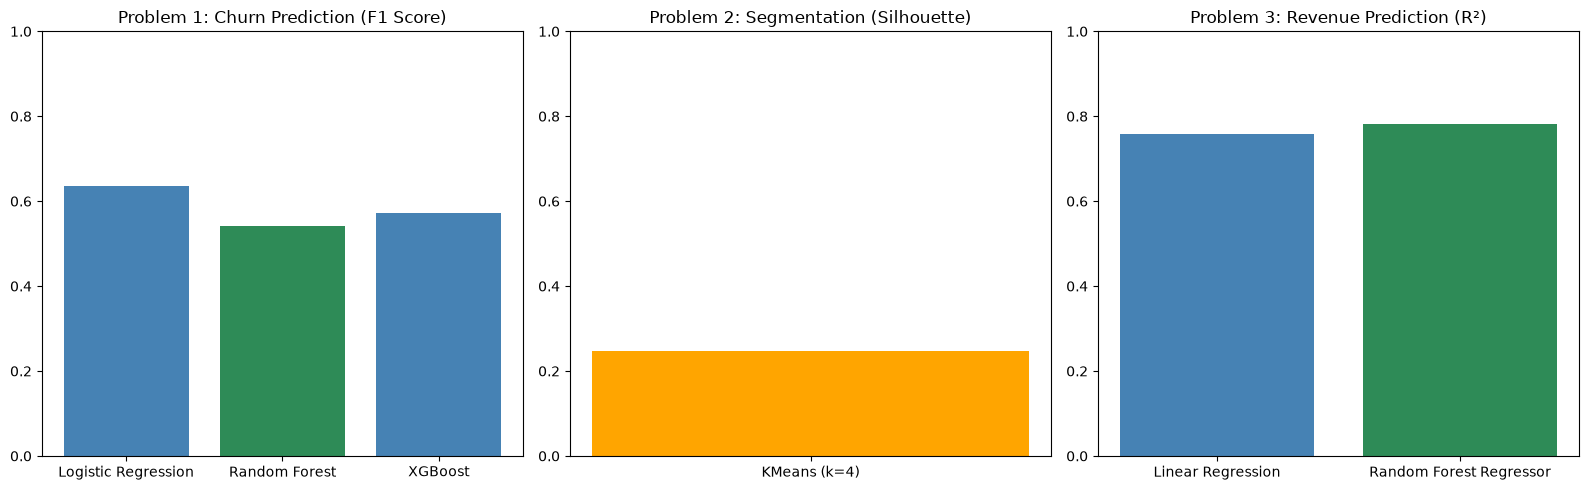

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(churn_results['ModelName'], churn_results['F1Score'], color=['steelblue', 'seagreen'])
axes[0].set_title('Problem 1: Churn Prediction (F1 Score)')
axes[0].set_ylim(0, 1)

axes[1].bar(['KMeans (k=4)'], [segmentation_results['SilhouetteScore'].iloc[0]], color='orange')
axes[1].set_title('Problem 2: Segmentation (Silhouette)')
axes[1].set_ylim(0, 1)

axes[2].bar(revenue_results['ModelName'], revenue_results['Test_R2'], color=['steelblue', 'seagreen'])
axes[2].set_title('Problem 3: Revenue Prediction (R²)')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('overall_model_evaluation_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
final_summary = pd.DataFrame({
    'Problem': ['Churn Prediction', 'Customer Segmentation', 'Revenue Prediction'],
    'Best_Model': ['Logistic Regression', 'KMeans (k=4)', 'Random Forest Regressor'],
    'Key_Metric': ['F1 Score', 'Silhouette Score', 'R²'],
    'Score': [0.635, 0.2473, 0.781]
})
final_summary.to_csv('final_model_evaluation_summary.csv', index=False)
final_summary

,Problem,Best_Model,Key_Metric,Score
0,Churn Prediction,Logistic Regression,F1 Score,0.6350
1,Customer Segmentation,KMeans (k=4),Silhouette Score,0.2473
2,Revenue Prediction,Random Forest Regressor,R²,0.7810
